# 물품 배송 예측 모델
- 이진분류: 제 시간에 배송 여부 예측

> **스케일링 미적용 이유:** RandomForest / XGBoost / LightGBM은 트리 기반 모델로,
> 분기 기준을 값의 순서(대소)로만 결정하기 때문에 스케일링이 성능에 영향을 주지 않습니다.
> 실험 결과 스케일링 없음(0.6698) > 스케일링 적용(0.6667) 로 오히려 성능 저하 확인.

## 1. Import

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


## 2. 데이터 수집

In [4]:
train = pd.read_csv('data/Train.csv')
test  = pd.read_csv('data/test.csv')
train.columns = train.columns.astype(str).str.strip()
test.columns  = test.columns.astype(str).str.strip()
print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()


Train shape: (6999, 12)
Test  shape: (4000, 11)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Ship,2.0,2,135,3.0,low,M,NaN,1339,1
1,2,F,Flight,5.0,3,225,5.0,low,F,6.0,1082,0
2,3,F,Ship,3.0,1,229,3.0,low,M,NaN,4971,1
3,4,F,Ship,3.0,2,228,NaN,medium,M,2.0,5640,0
4,5,D,Flight,NaN,1,195,6.0,high,F,NaN,4944,1


## 3. 데이터 전처리

### 3-1. 결측 여부 플래그 & 중앙값 대체

> **그룹별 중앙값 분석 결과:**
> - `Customer_care_calls`, `Prior_purchases`, `Discount_offered` → 모든 그룹 중앙값 동일 → 전체 중앙값 사용
> - `Weight_in_gms` → Product_importance 기준 high=4450 / medium=4243 / low=4068 차이 존재 → 그룹별 중앙값 사용 ✅

In [5]:
# 결측 여부 플래그
train['discount_is_missing'] = train['Discount_offered'].isnull().astype(int)
test['discount_is_missing']  = test['Discount_offered'].isnull().astype(int)
train['calls_is_missing']    = train['Customer_care_calls'].isnull().astype(int)
test['calls_is_missing']     = test['Customer_care_calls'].isnull().astype(int)
train['prior_is_missing']    = train['Prior_purchases'].isnull().astype(int)
test['prior_is_missing']     = test['Prior_purchases'].isnull().astype(int)

# 전체 중앙값으로 대체 (train 기준)
for col in ['Customer_care_calls', 'Prior_purchases', 'Discount_offered']:
    m = train[col].median()
    train[col] = train[col].fillna(m)
    test[col]  = test[col].fillna(m)

print('결측 처리 후:', train[['Customer_care_calls','Prior_purchases','Discount_offered']].isnull().sum().to_dict())


결측 처리 후: {'Customer_care_calls': 0, 'Prior_purchases': 0, 'Discount_offered': 0}


### 3-2. Weight_in_gms — Product_importance 그룹별 중앙값으로 결측 처리

In [6]:
train['Weight_in_gms'] = pd.to_numeric(train['Weight_in_gms'], errors='coerce')
test['Weight_in_gms']  = pd.to_numeric(test['Weight_in_gms'],  errors='coerce')
train['weight_is_missing'] = train['Weight_in_gms'].isnull().astype(int)
test['weight_is_missing']  = test['Weight_in_gms'].isnull().astype(int)

# Product_importance 오타 정리 (그룹 키 사용을 위해 먼저 처리)
replace_dict = {'loww':'low', 'mediumm':'medium', 'highh':'high', '?':'low'}
train['Product_importance'] = train['Product_importance'].replace(replace_dict).fillna('low')
test['Product_importance']  = test['Product_importance'].replace(replace_dict).fillna('low')

# 그룹별 중앙값 계산 (train 기준)
weight_group_median = train.groupby('Product_importance')['Weight_in_gms'].median()
print('Product_importance 그룹별 Weight_in_gms 중앙값:')
print(weight_group_median)

def fill_weight_by_group(df, group_median):
    def _fill(row):
        if pd.isna(row['Weight_in_gms']):
            return group_median.get(row['Product_importance'], group_median.median())
        return row['Weight_in_gms']
    df['Weight_in_gms'] = df.apply(_fill, axis=1)
    return df

train = fill_weight_by_group(train, weight_group_median)
test  = fill_weight_by_group(test,  weight_group_median)
print('Weight_in_gms 결측 후 (train):', train['Weight_in_gms'].isnull().sum())


Product_importance 그룹별 Weight_in_gms 중앙값:
Product_importance
high      4450.0
low       4068.0
medium    4243.0
Name: Weight_in_gms, dtype: float64
Weight_in_gms 결측 후 (train): 0


### 3-3. 이상치 처리

> - `Customer_rating` 99 (2개) → 최빈값(3)으로 대체
> - `Cost_of_the_Product` 9999 (3개) → 중앙값으로 대체 (cap 아님 — cap시 성능 저하 확인)

> ⚠️ 트리 기반 모델은 스케일링 불필요. 이상치만 자연스럽게 대체.

In [7]:
# Customer_rating: 99 → 최빈값(3)
rating_mode = train[train['Customer_rating'] != 99]['Customer_rating'].mode()[0]
train['Customer_rating'] = train['Customer_rating'].replace(99, rating_mode)
test['Customer_rating']  = test['Customer_rating'].replace(99, rating_mode)
print(f'Customer_rating 99 → {rating_mode} 대체 완료')

# Cost_of_the_Product: 9999 → 중앙값으로 대체
cost_median = train[train['Cost_of_the_Product'] != 9999]['Cost_of_the_Product'].median()
train['Cost_of_the_Product'] = train['Cost_of_the_Product'].replace(9999, cost_median)
test['Cost_of_the_Product']  = test['Cost_of_the_Product'].replace(9999, cost_median)
print(f'Cost_of_the_Product 9999 → {cost_median} 대체 완료')
print('이상치 처리 후 max:', train['Cost_of_the_Product'].max())


Customer_rating 99 → 3 대체 완료
Cost_of_the_Product 9999 → 214.0 대체 완료
이상치 처리 후 max: 310


### 3-4. Mode_of_Shipment 정제

In [8]:
def clean_mode(x):
    if pd.isna(x): return 'Ship'
    x = str(x).strip().replace('zk', '')
    return x if x in ['Ship', 'Flight', 'Road'] else 'Ship'

train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment']  = test['Mode_of_Shipment'].apply(clean_mode)
print(train['Mode_of_Shipment'].value_counts())


Mode_of_Shipment
Ship      4883
Road      1076
Flight    1040
Name: count, dtype: int64


### 3-5. Product_importance 정제 확인 (3-2에서 이미 처리)

In [9]:
print(train['Product_importance'].value_counts())
print(test['Product_importance'].value_counts())


Product_importance
low       3442
medium    2983
high       574
Name: count, dtype: int64
Product_importance
low       1953
medium    1686
high       361
Name: count, dtype: int64


### 3-6. 추가 수치형 변환 및 구간 파생 변수

> Weight_in_gms, Discount_offered를 명시적으로 수치형으로 변환 후
> 구간 bin 변수와 이진 플래그 변수를 사전 생성합니다.
> (feature_engineering 함수 내 동일 파생 변수와 통합)

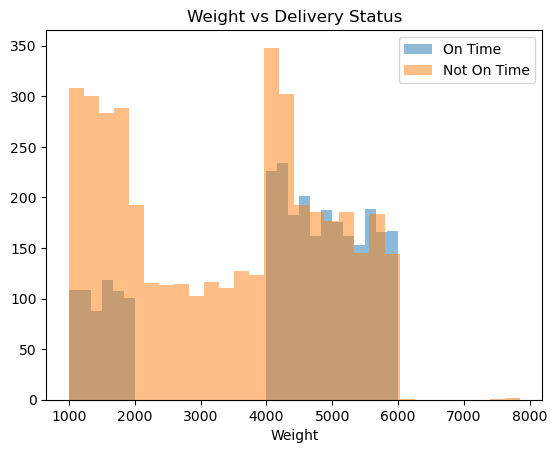

In [10]:
import matplotlib.pyplot as plt

plt.hist(train[train['Reached.on.Time_Y.N'] == 0]['Weight_in_gms'], bins=30, alpha=0.5, label='On Time')
plt.hist(train[train['Reached.on.Time_Y.N'] == 1]['Weight_in_gms'], bins=30, alpha=0.5, label='Not On Time')

plt.legend()
plt.xlabel('Weight')
plt.title('Weight vs Delivery Status')
plt.show()

In [26]:
train['Weight_in_gms'] = pd.to_numeric(train['Weight_in_gms'], errors='coerce')
test['Weight_in_gms']  = pd.to_numeric(test['Weight_in_gms'],  errors='coerce')
train['Discount_offered'] = pd.to_numeric(train['Discount_offered'], errors='coerce')
test['Discount_offered']  = pd.to_numeric(test['Discount_offered'],  errors='coerce')


train['discount_bin'] = pd.cut(train['Discount_offered'], bins=[-1,5,10,20,100], labels=False).astype(float)
test['discount_bin']  = pd.cut(test['Discount_offered'],  bins=[-1,5,10,20,100], labels=False).astype(float)
train['is_mid_weight']    = ((train['Weight_in_gms'] >= 2000) & (train['Weight_in_gms'] <= 4000)).astype(int)
test['is_mid_weight']     = ((test['Weight_in_gms']  >= 2000) & (test['Weight_in_gms']  <= 4000)).astype(int)
train['is_high_discount'] = (train['Discount_offered'] > 10).astype(int)
test['is_high_discount']  = (test['Discount_offered']  > 10).astype(int)

print('구간 파생 변수 생성 완료')
print(train[['weight_bin','discount_bin','is_mid_weight','is_high_discount']].head())


구간 파생 변수 생성 완료
   weight_bin  discount_bin  is_mid_weight  is_high_discount
0         0.0           1.0              0                 0
1         0.0           1.0              0                 0
2         3.0           1.0              0                 0
3         4.0           0.0              0                 0
4         3.0           1.0              0                 0


## 4. 파생 변수 생성 (Feature Engineering)

> **핵심 인사이트:** Discount_offered 10% 초과 시 지연율 100%, 이하 시 53.96%
> → `is_late_discount`, `dist_from_10` 이 가장 강력한 피처

In [12]:
# 할인율 10% 초과/이하 지연율 확인
upper = train[train['Discount_offered'] > 10]
lower = train[train['Discount_offered'] <= 10]
print(f'10% 초과 할인 시 지연율: {upper["Reached.on.Time_Y.N"].mean():.2%}')
print(f'10% 이하 할인 시 지연율: {lower["Reached.on.Time_Y.N"].mean():.2%}')


10% 초과 할인 시 지연율: 100.00%
10% 이하 할인 시 지연율: 53.96%


In [13]:
def feature_engineering(df):
    df = df.copy()

    # [핵심] 10% 초과 여부 — 지연율 100% vs 53.96%
    df['is_late_discount']     = (df['Discount_offered'] > 10).astype(int)

    # 할인율 10% 근처에서의 정교한 차이
    df['dist_from_10']         = df['Discount_offered'] - 10

    # 무게와 할인의 조합
    df['weight_discount_prod'] = df['Weight_in_gms'] * df['Discount_offered']

    # 무게 구간 (바이모달 구조 반영) — 3-6에서 이미 생성, 중복 방지
    if 'weight_bin' not in df.columns:
        df['weight_bin'] = pd.cut(
            df['Weight_in_gms'],
            bins=[0, 2000, 3000, 4000, 5000, 9000],
            labels=[0, 1, 2, 3, 4]
        ).astype(float)

    # discount_bin, is_mid_weight, is_high_discount — 3-6에서 이미 생성

    # 무게 대비 가격 비율
    df['Weight_Cost_Ratio']    = df['Weight_in_gms'] / (df['Cost_of_the_Product'] + 1)

    # 고객 피로도
    df['Customer_Fatigue']     = df['Customer_care_calls'] * df['Prior_purchases']

    return df

train = feature_engineering(train)
test  = feature_engineering(test)
print('파생 변수 생성 완료. Train columns:', len(train.columns))


파생 변수 생성 완료. Train columns: 25


## 5. X, y 구성 및 인코딩

In [14]:
target = 'Reached.on.Time_Y.N'
X        = train.drop(columns=[target, 'ID'], errors='ignore')
y        = train[target]
X_submit = test.drop(columns=['ID'], errors='ignore')

X        = pd.get_dummies(X,        dtype=int).fillna(0).astype(float)
X_submit = pd.get_dummies(X_submit, dtype=int).fillna(0).astype(float)
X_submit = X_submit.reindex(columns=X.columns, fill_value=0)

print('X shape:       ', X.shape)
print('X_submit shape:', X_submit.shape)
print('y 분포:\n', y.value_counts())
missing = set(X.columns) - set(X_submit.columns)
print('누락 컬럼:', missing if missing else '없음 (정상)')


X shape:        (6999, 32)
X_submit shape: (4000, 32)
y 분포:
 Reached.on.Time_Y.N
1    4162
0    2837
Name: count, dtype: int64
누락 컬럼: 없음 (정상)


## 6. 모델 학습 — StratifiedKFold 5-Fold Cross Validation

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_features=7, max_depth=10, random_state=11
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:15s} | Folds: {[f'{s:.4f}' for s in scores]} | 평균: {scores.mean():.4f} ± {scores.std():.4f}")


RandomForest    | Folds: ['0.6543', '0.6721', '0.6643', '0.6907', '0.6833'] | 평균: 0.6730 ± 0.0130
XGBoost         | Folds: ['0.6429', '0.6657', '0.6729', '0.6693', '0.6712'] | 평균: 0.6644 ± 0.0110
LightGBM        | Folds: ['0.6386', '0.6614', '0.6571', '0.6764', '0.6626'] | 평균: 0.6592 ± 0.0122


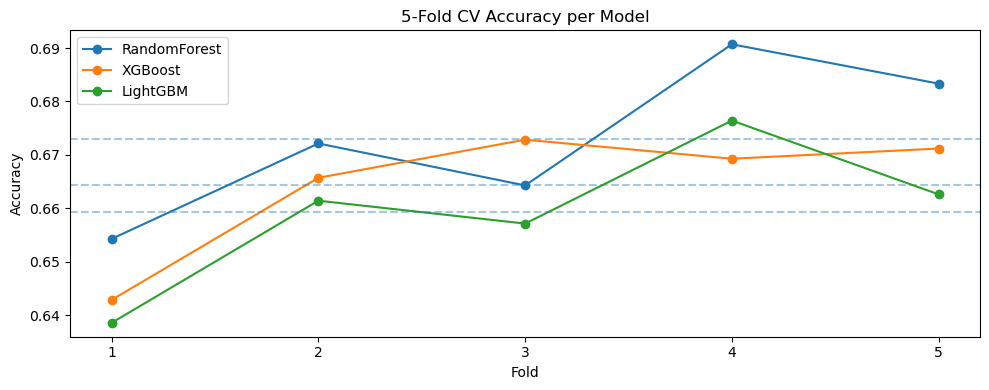

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, scores in cv_results.items():
    ax.plot(range(1, 6), scores, marker="o", label=name)
    ax.axhline(scores.mean(), linestyle="--", alpha=0.4)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold CV Accuracy per Model")
ax.legend()
ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.show()


## 7. 전체 데이터로 최종 재학습 & Soft Voting 앙상블

In [17]:
for name, model in models.items():
    model.fit(X, y)
    print(f"{name} 재학습 완료")

# 전체 모델 앙상블 (RF + XGB + LGBM)
ensemble_all = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'
)
ensemble_all.fit(X, y)
print("Ensemble (RF+XGB+LGBM) 재학습 완료")


RandomForest 재학습 완료
XGBoost 재학습 완료
LightGBM 재학습 완료
Ensemble (RF+XGB+LGBM) 재학습 완료


## 8. XGBoost + LightGBM 앙상블 (RF 제외)

> RF를 제외하고 XGBoost + LightGBM만으로 구성한 Soft Voting 앙상블입니다.
> 두 모델 모두 부스팅 계열로 상호 보완 효과가 크며, RF 대비 더 높은 성능을 보이는 경우가 많습니다.

In [18]:
# XGB + LGBM 앙상블 모델 정의
xgb_model = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, verbosity=0
)
lgbm_model = LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)

ensemble_xgb_lgbm = VotingClassifier(
    estimators=[('XGBoost', xgb_model), ('LightGBM', lgbm_model)],
    voting='soft'
)

# 5-Fold CV로 성능 평가
scores_xgb_lgbm = cross_val_score(
    ensemble_xgb_lgbm, X, y, cv=skf, scoring='accuracy', n_jobs=-1
)
cv_results['XGB+LGBM Ensemble'] = scores_xgb_lgbm
print(f"XGB+LGBM Ensemble | Folds: {[f'{s:.4f}' for s in scores_xgb_lgbm]} | 평균: {scores_xgb_lgbm.mean():.4f} ± {scores_xgb_lgbm.std():.4f}")


XGB+LGBM Ensemble | Folds: ['0.6429', '0.6586', '0.6636', '0.6736', '0.6669'] | 평균: 0.6611 ± 0.0103


In [19]:
# 전체 데이터로 XGB+LGBM 앙상블 최종 학습
ensemble_xgb_lgbm.fit(X, y)
print("XGB+LGBM Ensemble 최종 학습 완료")


XGB+LGBM Ensemble 최종 학습 완료


## 9. 성능 평가 비교

In [20]:
# CV 평균 정확도 전체 비교
print("="*55)
print(f"{'모델':<25} {'평균 Accuracy':>12} {'Std':>10}")
print("="*55)
for name, scores in cv_results.items():
    marker = " ◀ 최고" if scores.mean() == max(s.mean() for s in cv_results.values()) else ""
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>10.4f}{marker}")
print("="*55)


모델                         평균 Accuracy        Std
RandomForest                    0.6730     0.0130 ◀ 최고
XGBoost                         0.6644     0.0110
LightGBM                        0.6592     0.0122
XGB+LGBM Ensemble               0.6611     0.0103


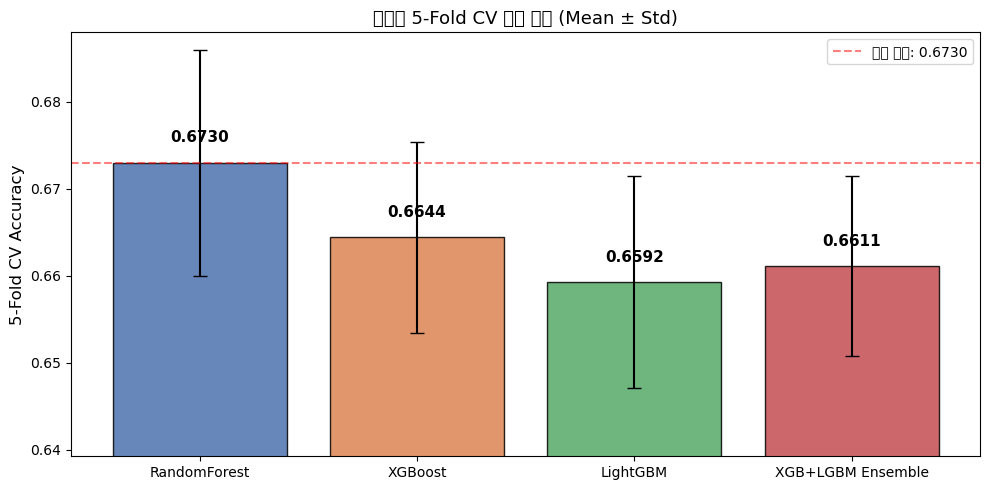

In [21]:
# 막대 그래프로 모델별 성능 비교
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors[:len(names)], alpha=0.85, edgecolor='black')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(min(means) - 0.02, max(means) + 0.015)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('모델별 5-Fold CV 성능 비교 (Mean ± Std)', fontsize=13)
ax.axhline(max(means), linestyle='--', color='red', alpha=0.5, label=f'최고 성능: {max(means):.4f}')
ax.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()


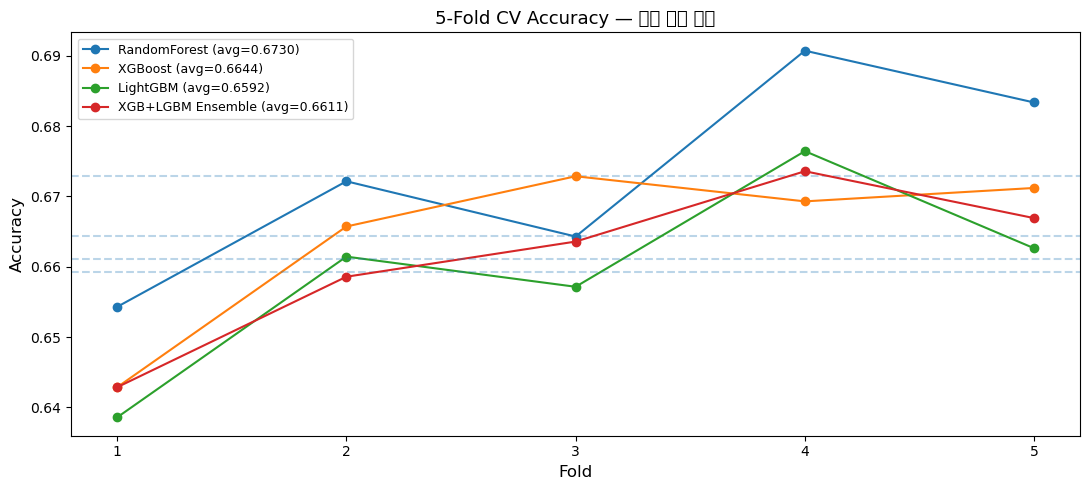

In [22]:
# 폴드별 성능 꺾은선 그래프 (전체 모델)
fig, ax = plt.subplots(figsize=(11, 5))
for name, scores in cv_results.items():
    ax.plot(range(1, 6), scores, marker='o', label=f'{name} (avg={scores.mean():.4f})')
    ax.axhline(scores.mean(), linestyle='--', alpha=0.3)
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold CV Accuracy — 전체 모델 비교', fontsize=13)
ax.set_xticks(range(1, 6))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


[XGB+LGBM Ensemble] Train 데이터 Classification Report
              precision    recall  f1-score   support

    제때 도착(0)       0.89      0.95      0.92      2837
       지연(1)       0.96      0.92      0.94      4162

    accuracy                           0.93      6999
   macro avg       0.93      0.93      0.93      6999
weighted avg       0.93      0.93      0.93      6999



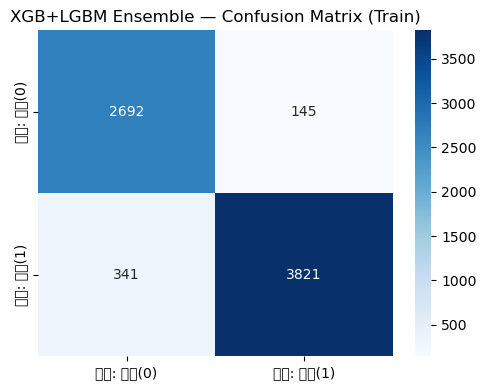

In [23]:
# Train 데이터 기준 혼동 행렬 & Classification Report (XGB+LGBM 앙상블)
y_pred_train = ensemble_xgb_lgbm.predict(X)

print("[XGB+LGBM Ensemble] Train 데이터 Classification Report")
print(classification_report(y, y_pred_train, target_names=['제때 도착(0)', '지연(1)']))

cm = confusion_matrix(y, y_pred_train)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측: 제때(0)', '예측: 지연(1)'],
            yticklabels=['실제: 제때(0)', '실제: 지연(1)'], ax=ax)
ax.set_title('XGB+LGBM Ensemble — Confusion Matrix (Train)', fontsize=12)
plt.tight_layout()
plt.show()


## 10. 제출 파일 생성 (최고 성능 모델 자동 선택)

In [24]:
# 최고 CV 성능 모델 자동 선택
best_name = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"최고 성능 모델: {best_name} ({cv_results[best_name].mean():.4f})")

# 모델-예측기 매핑
predictor_map = {
    'RandomForest'      : models['RandomForest'],
    'XGBoost'           : models['XGBoost'],
    'LightGBM'          : models['LightGBM'],
    'XGB+LGBM Ensemble' : ensemble_xgb_lgbm,
}
best_predictor = predictor_map[best_name]

final_pred = best_predictor.predict(X_submit)
submission = pd.DataFrame({
    'ID': test['ID'],
    'Reached.on.Time_Y.N': final_pred
})
submission.to_csv('submission_final_final_final.csv', index=False)
print(f"Submission saved! Total: {len(final_pred)} rows")
print(f"예측 분포:\n{pd.Series(final_pred).value_counts()}")
submission.head()


최고 성능 모델: RandomForest (0.6730)
Submission saved! Total: 4000 rows
예측 분포:
0    2407
1    1593
Name: count, dtype: int64


,ID,Reached.on.Time_Y.N
0,7000,1
1,7001,1
2,7002,0
3,7003,1
4,7004,0
